## 2.2 Análisis unidimensional de close

El análisis se centra en el precio de cierre (`close`) de los cinco activos, usando exclusivamente DEVELOPMENT: 214,165 observaciones, con 42,833 por activo. De esta variable se obtienen los retornos logarítmicos necesarios para construir la volatilidad futura, que continúa siendo la variable objetivo del pronóstico. Las demás columnas no se analizan en esta sección; las fechas y los símbolos se utilizan únicamente para identificar las observaciones y separar los activos.

### 2.2.1 Tipo de variable

`close` es una variable numérica continua, expresada en USDT por unidad del activo base. No es una variable categórica: no corresponden frecuencias de clases, categorías raras ni tratamiento de desbalance. Los precios se describen por activo para evitar mezclar escalas diferentes. No se detectaron valores nulos en esta columna dentro de DEVELOPMENT.

### 2.2.2 Estadísticos descriptivos

Cada fila de la tabla resume 42,833 observaciones. Se presentan media, mediana, desviación estándar muestral y percentiles 5 y 95. La [tabla completa de close](../outputs/tables/univariate_close_summary.csv) incluye también mínimo, máximo, percentiles 1 y 99 y cuartiles.

Los percentiles utilizan interpolación lineal. La desviación estándar descriptiva de los precios utiliza divisor N−1 (`ddof=1`); no representa la volatilidad de los retornos, cuya definición mantiene divisor 24 (`ddof=0`).

| Activo | Media | Mediana | Desv. estándar | P5 | P95 |
| --- | ---: | ---: | ---: | ---: | ---: |
| BTCUSDT | 45,804.96 | 40,554.17 | 25,338.61 | 15,372.90 | 98,647.39 |
| ETHUSDT | 2,247.83 | 2,110.24 | 967.56 | 450.26 | 3,888.85 |
| BNBUSDT | 376.40 | 328.00 | 187.84 | 29.04 | 661.28 |
| XRPUSDT | 0.8047 | 0.5577 | 0.6362 | 0.2712 | 2.3561 |
| SOLUSDT | 82.97 | 46.35 | 70.70 | 2.4129 | 207.08 |

### 2.2.3 Distribución, asimetría y curtosis

Los histogramas incluyen todos los cierres y utilizan 60 intervalos de igual anchura. El eje de frecuencias es logarítmico para hacer visibles los intervalos menos frecuentes; los precios permanecen en sus unidades originales. La asimetría y el exceso de curtosis se calculan con estimadores corregidos por sesgo. La referencia normal del exceso de curtosis es cero.



### 2.2.4 Valores extremos: boxplots e IQR

Se señalan cierres inferiores a Q1−1.5 IQR o superiores a Q3+1.5 IQR, con IQR=Q3−Q1, por separado para cada activo. En los boxplots, la caja representa Q1–Q3, la línea central es la mediana y los bigotes alcanzan las últimas observaciones dentro de las cercas. Los puntos exteriores son candidatos a extremos, no errores demostrados.

| Activo | Asimetría | Exceso de curtosis | Extremos IQR | Porcentaje |
| --- | ---: | ---: | ---: | ---: |
| BTCUSDT | 0.803 | -0.188 | 0 | 0.00% |
| ETHUSDT | 0.128 | -0.478 | 0 | 0.00% |
| BNBUSDT | -0.065 | -0.822 | 0 | 0.00% |
| XRPUSDT | 1.870 | 2.526 | 5,809 | 13.56% |
| SOLUSDT | 0.556 | -1.021 | 0 | 0.00% |

Los cierres señalados se conservan. No se eliminan, recortan ni winsorizan precios. Un nivel excepcional puede corresponder a otro periodo de cotización; la regla global de IQR no certifica errores de medición ni identifica por sí sola retornos extremos.

### 2.2.5 Normalidad

No se aplica una prueba de normalidad como requisito para utilizar `close`: la normalidad marginal del predictor no es una condición necesaria de los regresores considerados. Además, los precios forman una serie temporal y no se justifica interpretar las pruebas convencionales como si las observaciones fueran independientes. Con 42,833 valores por activo, una prueba puede detectar desviaciones pequeñas sin determinar su relevancia predictiva.

La [documentación de Shapiro–Wilk de SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html) advierte que el valor p puede no ser preciso para muestras mayores de 5,000. Se utilizan los histogramas y las medidas de forma como descripción, sin afirmar normalidad ni extraer una submuestra arbitraria para obtener un valor p.

### 2.2.6 Interpretación y relevancia

El precio de cierre presenta comportamientos diferentes entre activos. BTC y ETH tienen medianas de 40,554.17 y 2,110.24 USDT, respectivamente; esos niveles no permiten concluir cuál tiene mayor riesgo, porque corresponden a activos y escalas de precio diferentes. La desviación estándar del precio durante varios años tampoco equivale a la volatilidad de sus retornos en una ventana de 24 horas.

XRP tiene la mayor asimetría del cierre (1.870) y un exceso de curtosis positivo (2.526). La regla IQR señala 5,809 precios de cierre, equivalentes al 13.56%, todos por encima del límite superior de 1.411585 USDT. Esto describe precios altos frente a la distribución global de DEVELOPMENT; no demuestra que esas cotizaciones sean errores ni que los retornos de esas horas sean extremos.

En BTC, ETH, BNB y SOL no se señalan cierres bajo la regla IQR global. Ese resultado no implica normalidad ni ausencia de episodios volátiles: las cercas describen el nivel de precio acumulado durante todo el periodo. BNB presenta asimetría cercana a cero (-0.065), mientras que SOL combina una mediana de 46.35 USDT con una media de 82.97 USDT. La forma completa del histograma aporta información que no queda resumida por una única medida.

Para construir retornos se emplean cierres de horas consecutivas, sin atravesar huecos. `close` solo está disponible una vez cerrada la vela. Su presencia como predictor, sus rezagos y cualquier transformación deberán respetar ese instante de disponibilidad. No se eliminan los cierres señalados ni se decide una transformación a partir de estos gráficos.

### 2.2.7 Reproducibilidad

Los resultados corresponden al cálculo previo sobre DEVELOPMENT realizado mediante `src/09_univariate_development.py`. Se conservan sus filas de `close` en `outputs/tables/univariate_close_summary.csv`, sin recalcular estadísticas. La figura es `book/_static/figures/univariate_close.png`. El [notebook centrado en close](./10_close_univariate.ipynb) carga y presenta esos resultados guardados con su interpretación. Los archivos del análisis más amplio se conservan como antecedentes; no forman parte de la presentación de esta sección.


,symbol,variable,n,mean,median,std,min,p01,p05,q1,...,skew,excess_kurtosis,zero,iqr,lower,upper,below,above,flagged,percent
0,BTCUSDT,close,42833,45804.960692,40554.1700,25338.605430,9946.1400,10614.779600,15372.896000,26218.04000,...,0.802623,-0.187910,0,35144.57000,-26498.815000,114079.465000,0,0,0,0.000000
1,ETHUSDT,close,42833,2247.827738,2110.2400,967.556135,320.2300,353.986400,450.260000,1624.32000,...,0.128024,-0.477736,0,1377.37000,-441.735000,5067.745000,0,0,0,0.000000
2,BNBUSDT,close,42833,376.395571,328.0000,187.841725,18.2686,22.972356,29.044940,251.00000,...,-0.064641,-0.822136,0,312.40000,-217.600000,1032.000000,0,0,0,0.000000
3,XRPUSDT,close,42833,0.804721,0.5577,0.636231,0.1792,0.236973,0.271244,0.44611,...,1.869829,2.526474,0,0.38619,-0.133175,1.411585,0,5809,5809,13.561973
4,SOLUSDT,close,42833,82.968698,46.3460,70.697997,1.1832,1.539728,2.412900,21.53000,...,0.555825,-1.021309,0,123.54000,-163.780000,330.380000,0,0,0,0.000000


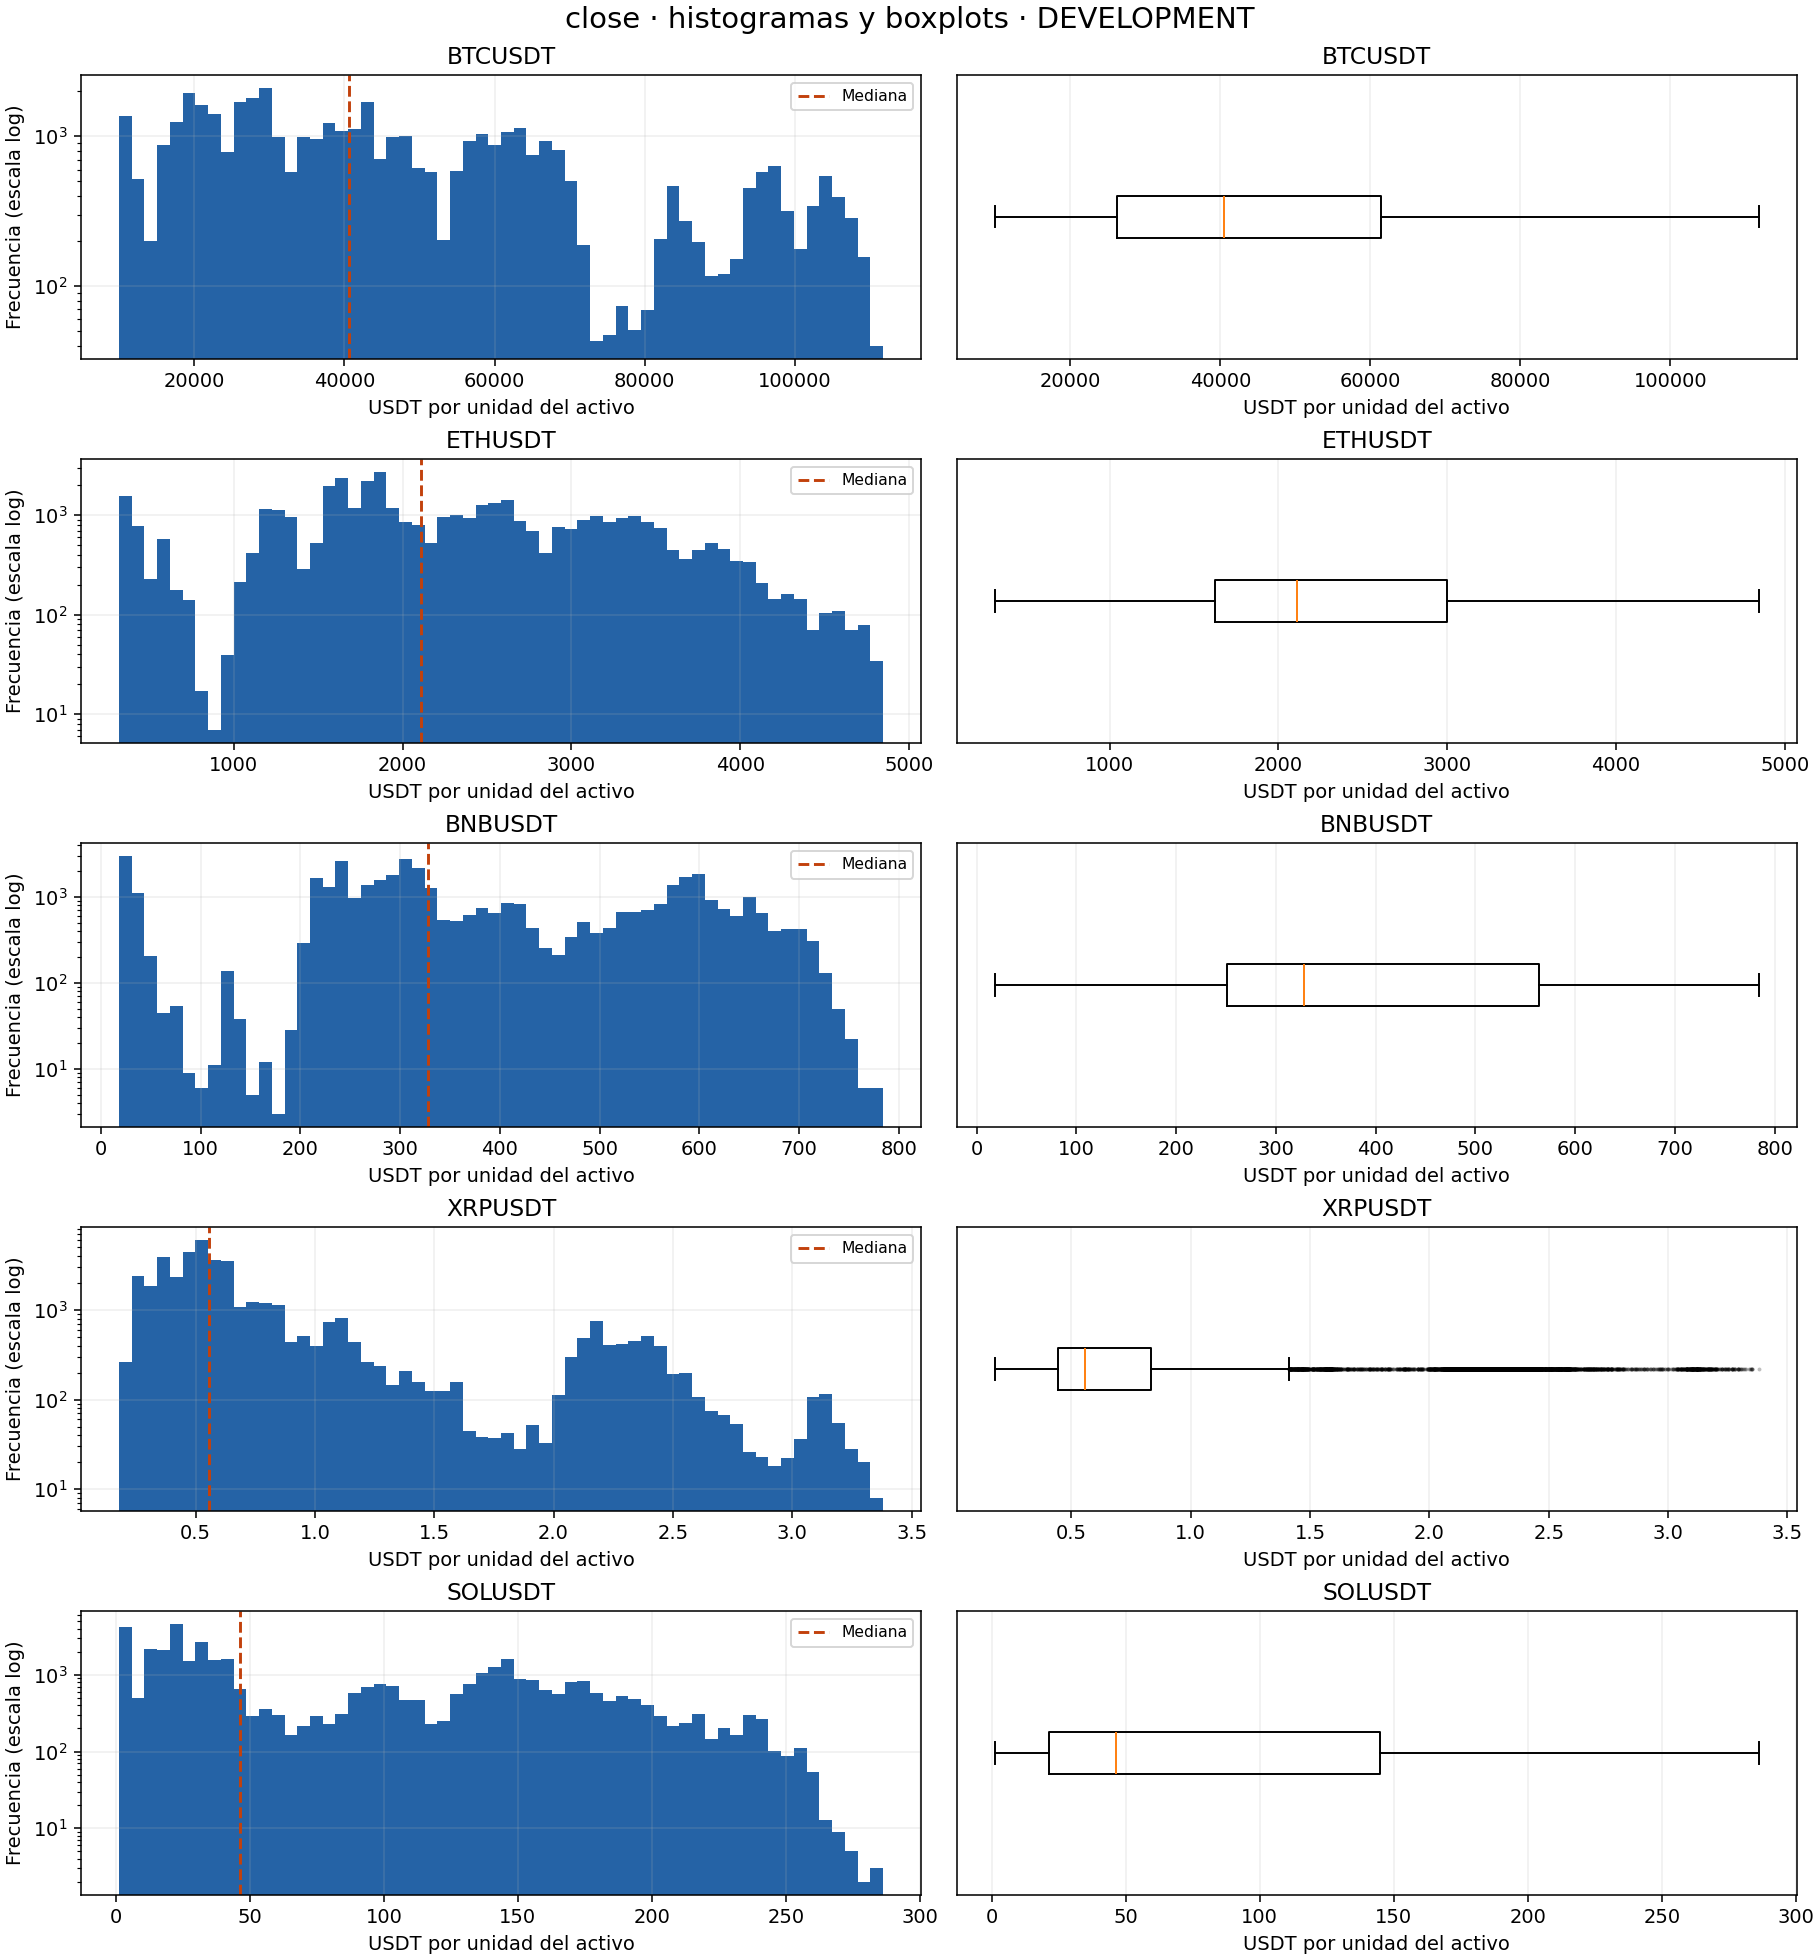

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'outputs/tables/univariate_close_summary.csv').is_file())
# Presentación de resultados previamente calculados; no recalcula estadísticas.
summary = pd.read_csv(ROOT / 'outputs/tables/univariate_close_summary.csv')
assert len(summary) == 5 and summary['variable'].eq('close').all()
display(summary)
display(Image(filename=str(ROOT / 'book/_static/figures/univariate_close.png')))
